### analyzing data from WHO pdfs
#### joey suen

In [55]:
# packages
import pandas as pd
import re
from pathlib import Path
import matplotlib.pyplot as plt

# import data into dictionary
data = {}

root = Path().resolve().parent
directory = root / "data/processed"
for file in directory.iterdir():
    data[file.stem] = pd.read_parquet(file)

research questions:

1. Is it true that assessed contributions have actually decreased over time while voluntary contributions have grown? \
    a. In (inflation-adjusted) absolute terms? \
    b. As a share of total contributions to WHO? 

2. If 1 is true, was there a turning point or just a gradual shift? 

In [43]:
g1 = data["group1"]
# column of focus: "current_year_assessment"

g3 = data["group3"]
# column of focus: "grand_total"
print(g3.columns)

Index(['contributor', 'voluntary_contributions_specified',
       'special_programme_for_research_and_training_in_tropical_diseases',
       'stop_tb_partnership',
       'special_programme_on_research_development_and_training_in_human_reproduction',
       'roll_back_malaria_partnership',
       'water_supply_and_sanitation_collaborative_council',
       'core_voluntary_contributions_account', 'voluntary_contributions_core',
       'grand_total', 'file', 'year', 'region', 'income_group',
       'contingency_fund_for_emergencies',
       'special_programmes_and_collaborative_arrangements',
       'outbreak_and_crisis_response'],
      dtype='object')


#### potential issue:
The data is lacking on assessed contributions beyond 2008. Group 2 has some information (see "biennial_assessment") but group 3 solely has information on voluntary contributions. I may need to look for more data on assessed contributions to be able to make any inference.
In particular, the data has almost no overlap in data on assessed and voluntary contributions. Each year only has one or the other.

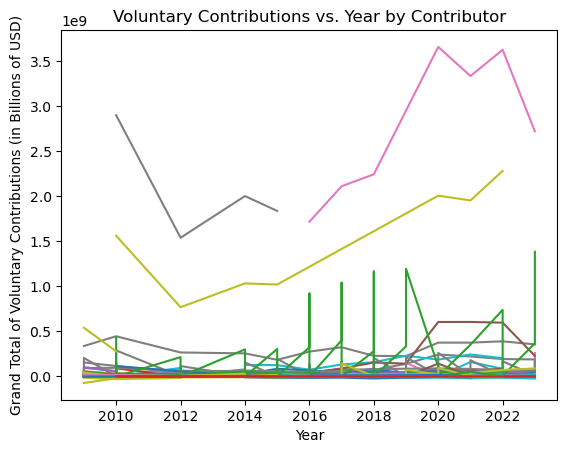

1118

In [38]:
# graphing grand_total for each contributor across the years

for member, group in g3.groupby("contributor"):
    plt.plot(group["year"], group["grand_total"], label=member)

plt.xlabel("Year")
plt.ylabel("Grand Total of Voluntary Contributions (in Billions of USD)")
plt.title("Voluntary Contributions vs. Year by Contributor")
plt.show()

len(g3.groupby("contributor"))

The above graph is extremely messy. There are a few outliers of very high voluntary contributions that make it difficult to look at the majority of contributors. Even then, there are so many different contributors (1118) that it's difficult to draw any sort of inference from this graph.

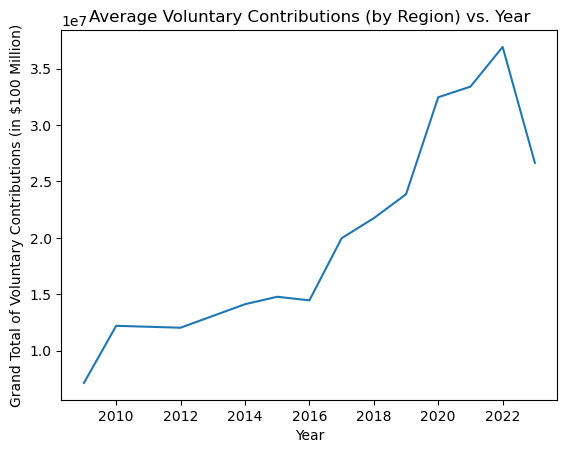

In [54]:
# plot of average voluntary contributions by year

g3.groupby("year")["grand_total"].mean().plot()

plt.xlabel("Year")
plt.ylabel("Grand Total of Voluntary Contributions (in $100 Million)")
plt.title("Average Voluntary Contributions (by Region) vs. Year")
plt.show()

This plot is a graph of the voluntary contributions averaged across all contributors against year. This graph ignores too much information, but it at least shows that the average voluntary contributions increases by year until 2022, where it takes a dive. One hypothesis would be that COVID-19 had an impact on this.

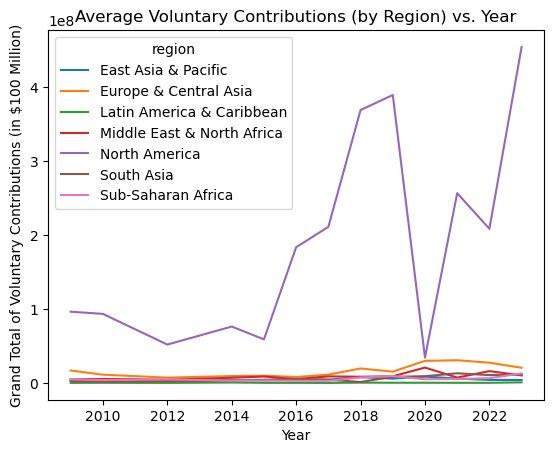

In [ ]:
# plot of average voluntary contributions (by region) by year

g3.groupby(["region", "year"])["grand_total"].mean().unstack(0).plot()

plt.xlabel("Year")
plt.ylabel("Grand Total of Voluntary Contributions (in $100 Million)")
plt.title("Average Voluntary Contributions (by Region) vs. Year")
plt.show()

North America's voluntary contributions dwarfs all other regions, making it difficult to read into other regions. It's very interesting to see the nose dive in voluntary contributions during 2020, which could very well be related to COVID-19. Overall, there appeared to be a steep increase in voluntary contributions until 2020, and this increase seeemed to recover from 2022 to 2023. 

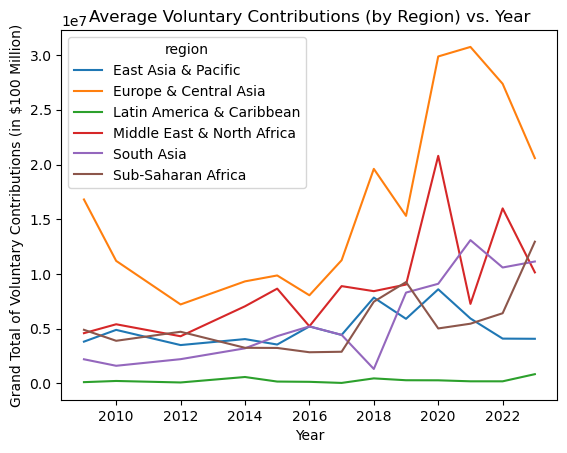

In [57]:
g3.groupby(["region", "year"])["grand_total"].mean().unstack(0).drop(columns="North America").plot()
plt.xlabel("Year")
plt.ylabel("Grand Total of Voluntary Contributions (in $100 Million)")
plt.title("Average Voluntary Contributions (by Region) vs. Year")
plt.show()

This plot makes it far easier to see the trends in voluntary contributions for regions aside from North America. Aside from Latin America & Carribea, all regions show a general increase. The effects of COVID-19 are, interestingly, quite the opposite from North America for East Asia & Pacific, Middle East & North Africa, and Europe & Central Asia. All of these regions showed significant increases in voluntary contributions, followed by declines in voluntary contributions in subsequent years.

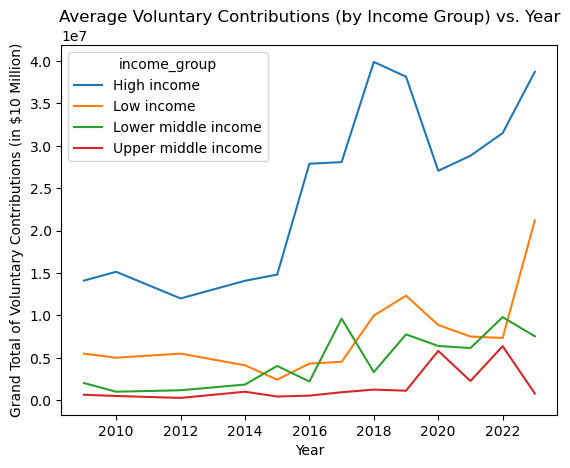

In [59]:
g3.groupby(["income_group", "year"])["grand_total"].mean().unstack(0).plot()
plt.xlabel("Year")
plt.ylabel("Grand Total of Voluntary Contributions (in $10 Million)")
plt.title("Average Voluntary Contributions (by Income Group) vs. Year")
plt.show()

The high income and low income group have both experienced massive increases in voluntary contributions, relative to their initial voluntary contributions in 2010. The low income group appears to have quadrupled from 2010 to 2023, while the high income group appears to have increased by a factor of approximately 8/3. The upper middle income group has seen no overall change, and the lower middle income group has seen a less significant increase in voluntary contributions.